

## 과제 목적
이번 과제는 수업에서 다룬 **Grain, Cardinality, JOIN, CTE, Window Function, 파생변수**를 실제 Olist 데이터에 직접 적용하는 것을 목표로 합니다. 단순히 SQL이 실행되는지 확인하는 것이 아니라, **결과가 분석적으로 올바른지 직접 검증하고 그 의미를 해석**해야 합니다. 생성형 AI를 사용할 수 있지만, AI가 제안한 쿼리나 해석을 그대로 제출하는 것이 아니라 **본인의 로컬 DB에서 실행 결과를 확인하고, 지표 정의와 JOIN 구조가 타당한지 판단**해야 합니다. 최종적으로 Colab에서 수행한 실험·그래프·해석을 기술블로그에 재구성합니다.

---
> 블로그에는 코드를 그대로 복사하기보다 **왜 이 쿼리를 썼는지 → 어떻게 검증했는지 → 결과를 어떻게 해석했는지**를 중심으로 작성하세요.



# 0. 환경 설정

일반 Colab Hosted Runtime의 `127.0.0.1`은 본인 PC가 아닙니다.  
로컬 MySQL에 접속하려면 **Colab Local Runtime**을 사용하세요.

로컬 터미널/PowerShell에서 Jupyter를 실행한 뒤 Colab의  
**연결 → 로컬 런타임에 연결** 메뉴에 URL을 입력합니다.

```bash
jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0 --NotebookApp.allow_credentials=True
```


In [2]:
%pip install -q pymysql sqlalchemy pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
from getpass import getpass
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import pandas as pd
import matplotlib.pyplot as plt

DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_NAME = "olist_sql_session"

DB_USER = input("MySQL 사용자명: ").strip()
DB_PASSWORD = getpass("MySQL 비밀번호: ")

url = URL.create(
    drivername="mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    query={"charset": "utf8mb4"},
)

engine = create_engine(url, pool_pre_ping=True)

def run_sql(sql: str) -> pd.DataFrame:
    """SELECT / WITH 쿼리를 실행하고 DataFrame으로 반환합니다."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("DB 연결 객체 생성 완료")


MySQL 사용자명: root
MySQL 비밀번호: ··········
DB 연결 객체 생성 완료


In [4]:
with engine.connect() as conn:
    info = conn.execute(
        text("SELECT VERSION() AS mysql_version, DATABASE() AS current_db;")
    ).mappings().one()

print(dict(info))
print("✅ 연결 성공")


{'mysql_version': '8.0.44', 'current_db': 'olist_sql_session'}
✅ 연결 성공


In [5]:
run_sql("SHOW TABLES;")


,Tables_in_olist_sql_session
0,olist_customers_dataset
1,olist_geolocation_dataset
2,olist_order_items_dataset
3,olist_order_payments_dataset
4,olist_order_reviews_dataset
5,olist_orders_dataset
6,olist_products_dataset
7,olist_sellers_dataset
8,order_mart
9,product_category_name_translation


# 1. 필수 과제

## 빈칸 작성 방식
- `__BLANK_n__` 부분만 올바른 SQL/Python 코드로 바꾸면 됩니다.
- 빈칸을 채워 실행한 뒤  **결과 검증 + 해석**까지 작성하세요.


## 1.1 Grain과 Cardinality 확인

세 테이블의 **한 행이 무엇을 의미하는지** 확인합니다.

- `olist_orders_dataset`
- `olist_order_items_dataset`
- `olist_order_payments_dataset`

### 목표
- 전체 행 수
- 고유 주문 수
- 한 주문이 여러 행으로 나타나는지 확인


In [8]:
# [1.1-A] orders
# 힌트: 고유 주문 수는 order_id에 DISTINCT를 적용합니다.

orders_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_orders_dataset;
"""

orders_grain_df = run_sql(orders_grain_sql)
orders_grain_df


,total_rows,distinct_orders
0,99441,99441


In [10]:
# [1.1-B] order_items
# 힌트: 한 주문 안에 여러 상품 행이 있을 수 있습니다.
# 전체 행 수와 고유 order_id 수의 차이를 확인하세요.

items_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_items_dataset;
"""

items_grain_df = run_sql(items_grain_sql)
items_grain_df


,total_rows,distinct_orders
0,112650,98666


In [11]:
# [1.1-C] payments
# 힌트: 한 주문에 결제 행이 여러 개 존재할 수 있습니다.

payments_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_payments_dataset;
"""

payments_grain_df = run_sql(payments_grain_sql)
payments_grain_df


,total_rows,distinct_orders
0,103886,99440


### 1.1 해석
- `orders`의 한 행: 하나의 주문, 전체 행과 고유 주문 수 99,441개로 동일하므로 1행 = 1주문이다.
- `order_items`의 한 행: 한 주문에 포함된 하나의 상품, 전체 112,650행 중 고유 주문 수는 98,666개이므로 한 주문이 여러 상품을 포함하는 것을 알 수 있다.
- `payments`의 한 행: 한 주문에 대한 하나의 결제 기록, 전체 103,886행 중 고유 주문 수가 99,440개 이므로 한 주문에 대한 결제 기록이 여러 개 존재함을 알 수 있다.
- `orders → order_items` 관계: 1:N
- `orders → payments` 관계: 1:N
- Grain을 확인하지 않고 JOIN하면 어떤 문제가 생길 수 있는지: JOIN하면 한 주문의 행이 여러 개로 늘어나거나 금액이 중복 계산되는 문제가 발생할 수 있다.


---

## 1.2 문법적으로 맞는 JOIN이 왜 잘못된 결과를 만들까?

배송 완료(`delivered`) 주문을 기준으로:
1. 주문 수
2. 상품 판매금액
3. 결제금액

을 먼저 **올바른 기준값**으로 계산한 뒤,  
`orders + order_items + payments`를 한 번에 JOIN한 결과와 비교합니다.


In [12]:
# [1.2-A] 올바른 기준값 계산
#
# 힌트
# - 주문 수: orders 단독
# - 상품 판매금액: orders + order_items만 JOIN
# - 결제금액: orders + payments만 JOIN
# - 세 지표 모두 delivered 주문만 사용
#
# 문자열 delivered는 따옴표를 포함해야 합니다.

correct_metric_sql = """
SELECT
    (
        SELECT COUNT(*)
        FROM olist_orders_dataset
        WHERE order_status = 'delivered'
    ) AS correct_order_count,

    (
        SELECT ROUND(SUM(oi.price), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_items_dataset AS oi
          ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
    ) AS correct_item_amount,

    (
        SELECT ROUND(SUM(p.payment_value), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_payments_dataset AS p
          ON o.order_id = p.order_id
        WHERE o.order_status = 'delivered'
    ) AS correct_payment_amount;
"""

correct_df = run_sql(correct_metric_sql)
correct_df


,correct_order_count,correct_item_amount,correct_payment_amount
0,96478,13221498.11,15422461.77


In [13]:
# [1.2-B] naive JOIN
#
# 힌트
# - orders ↔ order_items: order_id
# - orders ↔ payments: order_id
# - delivered 주문만 필터링
# - COUNT(*)는 JOIN된 결과 행 수
# - COUNT(DISTINCT o.order_id)는 JOIN 뒤 고유 주문 수

naive_join_sql = """
SELECT
    COUNT(*) AS joined_rows,
    COUNT(DISTINCT o.order_id) AS orders_after_join,
    ROUND(SUM(oi.price), 2) AS wrong_item_amount,
    ROUND(SUM(p.payment_value), 2) AS wrong_payment_amount
FROM olist_orders_dataset AS o
JOIN olist_order_items_dataset AS oi
  ON o.order_id = oi.order_id
JOIN olist_order_payments_dataset AS p
  ON o.order_id = p.order_id
WHERE o.order_status = 'delivered';
"""

naive_df = run_sql(naive_join_sql)
naive_df


,joined_rows,orders_after_join,wrong_item_amount,wrong_payment_amount
0,115035,96477,13813828.71,19776160.44


In [14]:
# [1.2-C] 금액 부풀림 비율
#
# 공식:
# (잘못 계산된 값 / 올바른 기준값 - 1) * 100

correct_item = float(correct_df.loc[0, "correct_item_amount"])
correct_payment = float(correct_df.loc[0, "correct_payment_amount"])
wrong_item = float(naive_df.loc[0, "wrong_item_amount"])
wrong_payment = float(naive_df.loc[0, "wrong_payment_amount"])

item_inflation_pct = (wrong_item  / correct_item  - 1) * 100
payment_inflation_pct = (wrong_payment   / correct_payment  - 1) * 100

print(f"상품 판매금액 증가율: {item_inflation_pct:.2f}%")
print(f"결제금액 증가율: {payment_inflation_pct:.2f}%")


상품 판매금액 증가율: 4.48%
결제금액 증가율: 28.23%


### 1.2 해석
1. JOIN 후 행 수가 주문 수보다 증가한 이유는?
order_items와 payments가 모두 orders와 1:N 관계이기 때문이다.
2. `COUNT(*)`와 `COUNT(DISTINCT o.order_id)`가 다른 이유는?
COUNT(*)는 JOIN 이후 생성된 모든 행을 세고, COUNT(DISTINCT o.order_id)는 같은 주문번호가 여러 번 등장하더라도 한 번만 계산한다.
3. 상품 판매금액과 결제금액 중 어느 쪽이 더 크게 부풀었는가?
결제금액
4. `SELECT DISTINCT`만으로 이 문제를 해결하면 안 되는 이유는?
상품 정보와 결제 정보가 서로 다르게 만들어져 완전히 동일하지 않기 때문에 DISTINCT만으로 제거할 수 없다.
5. JOIN 결과의 **한 행**은 무엇을 의미하게 되었는가?
JOIN 이후 한 행은 특정 주문의 상품 항목과 결제 기록이 결합된 하나의 조합을 의미한다.

---

## 1.3 주문 단위 분석 데이터 구성 + 배송 지연과 리뷰 분석

Mission 1의 Row Explosion을 피하기 위해 각 1:N 테이블을 **order_id 단위로 먼저 집계**합니다.

목표 Grain:

> **1 row = 1 order**

### 파생변수
- `delivery_days`: 실제 배송완료일 - 주문일
- `delay_days`: 실제 배송완료일 - 예상 배송일
- `is_delayed`: 실제 배송완료일이 예상 배송일보다 늦으면 1


In [17]:
# [1.3-A] 주문 단위 Mart 만들기
#
# item_summary 힌트
# - product_count: product_id의 고유 개수
# - seller_count: seller_id의 고유 개수
# - item_amount: price 합계
# - freight_amount: freight_value 합계
#
# payment_summary 힌트
# - payment_amount: payment_value 합계
# - max_installments: payment_installments 최대값
#
# review_summary 힌트
# - avg_review_score: review_score 평균
#
# 각 CTE의 GROUP BY 기준은 모두 order_id 입니다.

order_mart_sql = """
WITH item_summary AS (
    SELECT
        order_id,
        COUNT(*) AS item_count,
        COUNT(DISTINCT product_id) AS product_count,
        COUNT(DISTINCT seller_id) AS seller_count,
        SUM(price) AS item_amount,
        SUM(freight_value) AS freight_amount
    FROM olist_order_items_dataset
    GROUP BY order_id
),

payment_summary AS (
    SELECT
        order_id,
        COUNT(*) AS payment_count,
        SUM(payment_value) AS payment_amount,
        MAX(payment_installments) AS max_installments
    FROM olist_order_payments_dataset
    GROUP BY order_id
),

review_summary AS (
    SELECT
        order_id,
        COUNT(*) AS review_count,
        AVG(review_score) AS avg_review_score
    FROM olist_order_reviews_dataset
    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    c.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    i.item_count,
    i.product_count,
    i.seller_count,
    i.item_amount,
    i.freight_amount,

    p.payment_count,
    p.payment_amount,
    p.max_installments,

    r.review_count,
    r.avg_review_score,

    /* delivery_days = 실제 배송완료일 - 주문일 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp
        )
    END AS delivery_days,

    /* delay_days = 실제 배송완료일 - 예상 배송일
       양수: 지연 / 0: 예정일 / 음수: 조기 배송 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_estimated_delivery_date
        )
    END AS delay_days,

    /* 실제 배송완료일 > 예상 배송일 이면 1 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) > 0 THEN 1
        ELSE 0
    END AS is_delayed

FROM olist_orders_dataset AS o

LEFT JOIN olist_customers_dataset AS c
  ON o.customer_id = c.customer_id

LEFT JOIN item_summary AS i
  ON o.order_id = i.order_id

LEFT JOIN payment_summary AS p
  ON o.order_id = p.order_id

LEFT JOIN review_summary AS r
  ON o.order_id = r.order_id;
"""

order_mart_df = run_sql(order_mart_sql)
order_mart_df.head()


,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,item_count,product_count,...,item_amount,freight_amount,payment_count,payment_amount,max_installments,review_count,avg_review_score,delivery_days,delay_days,is_delayed
0,05ddf4cc62efcc6f34b8c693eaa2db01,b77ee5671feb9b6efce84cc804842024,5c64fc047d4115cc4be24c9c0c9503c2,DF,delivered,2018-07-03 18:18:34,2018-07-09 16:34:28,2018-07-25,1.0,1.0,...,69.99,18.59,1.0,88.58,4.0,1.0,5.0,6.0,-16.0,0.0
1,0bfa8870838091fe8171ed69f6b89fee,10f2beaf4d0f6f475d9f4cfdc9b05457,84a7bab3a01dd7085bf2b17082e6c8a4,SP,delivered,2018-08-22 10:21:13,2018-08-24 22:41:52,2018-08-28,2.0,1.0,...,49.98,14.88,1.0,64.86,1.0,1.0,5.0,2.0,-4.0,0.0
2,20f136d890c31a62486c809f91a5b098,e46db370a98dec564da620109436f09a,127d41455fd0ee4fe94ecd34b6b206b9,MG,delivered,2017-06-21 16:54:28,2017-07-03 14:39:54,2017-07-13,1.0,1.0,...,69.90,47.78,1.0,117.68,10.0,1.0,4.0,12.0,-10.0,0.0
3,22561cc73693742c65f9e31bd0e8df08,93e314b682a2da481b45a81ccdf91ef2,3e3bca450eb65febb63301472b833f4b,RJ,delivered,2017-05-23 08:58:15,2017-06-12 17:13:22,2017-06-21,1.0,1.0,...,387.49,17.46,1.0,404.95,10.0,1.0,5.0,20.0,-9.0,0.0
4,25e8002575a945e8d4ae84ca208daa50,e8ab8f389636432382f031e90d3606bb,42832ed9903e18991afc347bb4c28dac,SP,delivered,2018-06-18 07:49:22,2018-06-22 15:45:51,2018-07-05,1.0,1.0,...,79.90,24.17,1.0,104.07,1.0,1.0,4.0,4.0,-13.0,0.0


In [18]:
# [1.3-B] Grain 검증
#
# 목표: len(order_mart_df) == order_id 고유 개수
# 즉, 1 row = 1 order가 되어야 합니다.

total_rows = len(order_mart_df)
unique_orders = order_mart_df["order_id"].nunique()

print("전체 행 수:", total_rows)
print("고유 주문 수:", unique_orders)

assert total_rows == unique_orders


전체 행 수: 99441
고유 주문 수: 99441


In [19]:
# [1.3-C] 배송 상태별 리뷰 점수 비교
#
# 이번 단계는 SQL을 다시 길게 쓰기보다,
# 위에서 생성한 주문 단위 DataFrame을 이용해도 됩니다.
#
# 힌트
# - delivered 주문만 남기기
# - is_delayed, avg_review_score가 NULL인 행 제거
# - is_delayed 0 -> on_time / 1 -> delayed
# - delivery_status 기준 groupby
# - 평균 리뷰, 평균 배송일, 평균 지연일 계산

delivery_analysis_df = order_mart_df[
    (order_mart_df["order_status"] == "delivered")
    & order_mart_df["is_delayed"].notna()
    & order_mart_df["avg_review_score"].notna()
].copy()

delivery_analysis_df["delivery_status"] = delivery_analysis_df["is_delayed"].map(
    {0: "on_time", 1: "delayed"}
)

delivery_review_df = (
    delivery_analysis_df
    .groupby("delivery_status", as_index=False)
    .agg(
        order_count=("order_id", "count"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delay_days", "mean")
    )
)

delivery_review_df


,delivery_status,order_count,avg_review_score,avg_delivery_days,avg_delay_days
0,delayed,6381,2.271823,33.784360,10.518414
1,on_time,89443,4.290589,10.933701,-13.513366


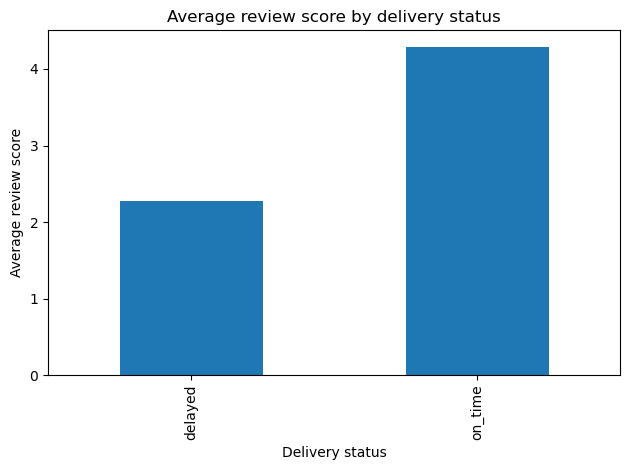

In [20]:
# [1.3-D] 시각화
#
# 힌트
# - kind = "bar"
# - x = "delivery_status"
# - y = "avg_review_score"

ax = delivery_review_df.plot(
    kind="bar",
    x="delivery_status",
    y="avg_review_score",
    legend=False
)

ax.set_title("Average review score by delivery status")
ax.set_xlabel("Delivery status")
ax.set_ylabel("Average review score")
plt.tight_layout()
plt.show()


### 1.3 해석
1. 정상 배송과 지연 배송의 평균 리뷰 점수는 어떻게 달랐는가?
정상 배송의 평균 리뷰 점수는 약 4.29점이었고, 지연 배송은 약 2.27점이었다. 지연 배송 주문의 평균 리뷰 점수가 정상 배송 주문보다 약 2.02점 낮게 나타났다.
2. `delay_days`와 `is_delayed`를 둘 다 만든 이유는?
is_delayed는 배송 지연 여부를 0과 1로 구분하는 변수이고, delay_days는 실제로 며칠 일찍 또는 늦게 배송되었는지를 나타내는 변수이다. 따라서 지연 여부뿐 아니라 지연 정도까지 함께 분석할 수 있다.
3. `order_mart`의 Grain은?
order_mart의 Grain은 1 row = 1 order이다.
4. 이 결과만으로 배송 지연이 리뷰 하락의 **원인**이라고 말할 수 있는가?
배송 지연이 리뷰 하락의 직접적인 원인이라고 단정할 수는 없다. 배송 지연과 낮은 리뷰 점수 사이의 연관성은 존재하지만 상품 품질, 가격 등의 다른 요인이 리뷰 점수에 영향을 주었을 가능성이 있기 때문이다.
5. 추가로 확인하고 싶은 변수는?
배송비




---

## 1.4 재구매 고객은 몇 명인가? — 지표 정의 비교

### 정의 A
모든 주문을 구매로 간주

### 정의 B
`delivered` 주문만 성공한 구매로 간주

### 핵심
- 실제 고객 식별자: `customer_unique_id`
- 고객별 주문 순서: `ROW_NUMBER()`
- 직전 주문일: `LAG()`
- 재구매 고객: 주문 2회 이상


In [21]:
# [1.4-A] 정의 A/B 재구매율 비교
#
# 힌트
# - 두 CTE 모두 customer_unique_id 기준 GROUP BY
# - 정의 B에만 delivered 필터
# - repeat customer는 order_count >= 2

repeat_customer_sql = """
WITH all_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
),

delivered_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    'all_orders' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM all_orders

UNION ALL

SELECT
    'delivered_only' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM delivered_orders;
"""

repeat_customer_df = run_sql(repeat_customer_sql)
repeat_customer_df


,definition,customer_count,repeat_customer_count,repeat_customer_rate_pct
0,all_orders,96096,2997.0,3.12
1,delivered_only,93358,2801.0,3.00


In [22]:
# [1.4-B] ROW_NUMBER + LAG
#
# 두 Window Function 모두:
# PARTITION BY customer_unique_id
# ORDER BY order_purchase_timestamp, order_id
#
# order_id를 두 번째 정렬 기준으로 넣는 이유:
# 같은 timestamp가 있어도 순서를 안정적으로 결정하기 위해서입니다.

customer_history_sql = """
WITH ordered_customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,

        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp, o.order_id
        ) AS order_number,

        LAG(o.order_purchase_timestamp) OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp, o.order_id
        ) AS previous_order_timestamp

    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
)

SELECT
    *,
    DATEDIFF(
        order_purchase_timestamp,
        previous_order_timestamp
    ) AS days_since_previous_order

FROM ordered_customer_orders
WHERE previous_order_timestamp IS NOT NULL;
"""

customer_history_df = run_sql(customer_history_sql)
customer_history_df.head()


,customer_unique_id,order_id,order_status,order_purchase_timestamp,order_number,previous_order_timestamp,days_since_previous_order
0,00172711b30d52eea8b313a7f2cced02,c306eca42d32507b970739b5b6a5a33a,canceled,2018-08-13 09:14:07,2,2018-07-28 00:23:49,16
1,004288347e5e88a27ded2bb23747066c,08204559bebd39e09ee52dcb56d8faa2,delivered,2018-01-14 07:36:54,2,2017-07-27 14:13:03,171
2,004b45ec5c64187465168251cd1c9c2f,9392c5e72885ad5aba87e6223ca9838d,delivered,2018-05-26 19:42:48,2,2017-09-01 12:11:23,267
3,0058f300f57d7b93c477a131a59b36c3,81a93b2fa39e104b865b2bc471c16008,delivered,2018-03-22 18:09:41,2,2018-02-19 17:11:34,31
4,00a39521eb40f7012db50455bf083460,cea3e6c11eb60acb9d8d4d51694832f8,delivered,2018-06-03 10:12:57,2,2018-05-23 20:14:21,11


In [24]:
# [1.4-C] 같은 날 발생한 후속 주문 수
#
# 힌트:
# days_since_previous_order == 0 인 행 개수

same_day_repeat_count = (
    customer_history_df["days_since_previous_order"] == 0
).sum()

print("same-day repeat rows:", same_day_repeat_count)


same-day repeat rows: 961


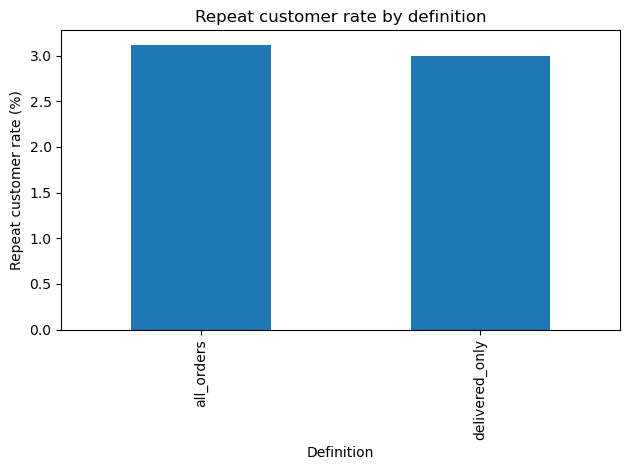

In [25]:
# [1.4-D] 정의 A/B 재구매율 시각화
#
# 힌트:
# kind = "bar"
# x = "definition"
# y = "repeat_customer_rate_pct"

ax = repeat_customer_df.plot(
    kind="bar",
    x="definition",
    y="repeat_customer_rate_pct",
    legend=False
)

ax.set_title("Repeat customer rate by definition")
ax.set_xlabel("Definition")
ax.set_ylabel("Repeat customer rate (%)")
plt.tight_layout()
plt.show()


### 1.4 해석
1. 왜 `customer_id`가 아니라 `customer_unique_id`를 사용해야 하는가?
고객의 반복 구매 행동을 추적하기 위해서는 실제 고객을 식별하는 customer_unique_id를 사용해야 한다.
2. 정의 A/B의 재구매율이 다른 이유는?
정의 A에는 배송 완료되지 않은 주문도 주문 횟수에 포함되기 때문에 일부 고객이 재구매 고객으로 분류되어 재구매율이 약간 높게 나타난다.
3. 본인은 어떤 정의가 더 적절하다고 보는가?
B, 취소되거나 완료되지 않은 주문까지 재구매로 포함하면 실제 구매 행동을 과대평가할 수 있기 때문이다.
4. 같은 날 발생한 후속 주문을 재구매로 볼 것인가?
아니다. 하나의 구매를 나누어 주문했거나 결제 과정에서 주문이 분리된 경우일 수도 있기 때문이다.
5. **SQL보다 지표 정의가 먼저**라는 말의 의미는?
재구매를 어떤 주문 상태까지 포함할지, 몇 회 이상을 재구매로 볼지, 같은 날 발생한 주문을 별도 구매로 인정할지에 따라 결과가 달라질 수 있다.


---

## 1.5 월별 매출 변화 + 카테고리 원인 분해

배송 완료 주문 기준, **2017-01 ~ 2018-08** 분석

### 계산
- 월별 매출
- 전월 매출
- 전월 대비 증감액
- MoM 증감률
- 가장 큰 감소 구간
- 해당 구간의 카테고리별 변화


In [26]:
# [1.5-A] 월별 매출 + LAG
#
# 힌트
# - month = DATE_FORMAT(order_purchase_timestamp, '%Y-%m')
# - revenue = SUM(oi.price)
# - order_count = COUNT(DISTINCT o.order_id)
# - customer_count = COUNT(DISTINCT c.customer_unique_id)
# - delivered만 사용
# - 기간: '2017-01-01' 이상, '2018-09-01' 미만
# - previous_revenue = LAG(revenue) OVER (ORDER BY month)

monthly_sales_sql = """
WITH monthly_sales AS (
    SELECT
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue,
        COUNT(DISTINCT o.order_id) AS order_count,
        COUNT(DISTINCT c.customer_unique_id) AS customer_count

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-01-01'
      AND o.order_purchase_timestamp <  '2018-09-01'

    GROUP BY DATE_FORMAT(
        o.order_purchase_timestamp,
        '%Y-%m'
    )
),

monthly_with_previous AS (
    SELECT
        month,
        revenue,
        order_count,
        customer_count,
        LAG(revenue) OVER (
            ORDER BY month
        ) AS previous_revenue
    FROM monthly_sales
)

SELECT
    month,
    ROUND(revenue, 2) AS revenue,
    order_count,
    customer_count,
    ROUND(previous_revenue, 2) AS previous_revenue,

    ROUND(
        revenue - previous_revenue,
        2
    ) AS mom_change,

    ROUND(
        100.0 * (revenue - previous_revenue)
        / NULLIF(previous_revenue, 0),
        2
    ) AS growth_rate_pct

FROM monthly_with_previous
ORDER BY month;
"""

monthly_sales_df = run_sql(monthly_sales_sql)
monthly_sales_df


,month,revenue,order_count,customer_count,previous_revenue,mom_change,growth_rate_pct
0,2017-01,111798.36,750,718,NaN,NaN,NaN
1,2017-02,234223.40,1653,1630,111798.36,122425.04,109.51
2,2017-03,359198.85,2546,2508,234223.40,124975.45,53.36
3,2017-04,340669.68,2303,2274,359198.85,-18529.17,-5.16
4,2017-05,489338.25,3546,3479,340669.68,148668.57,43.64
5,2017-06,421923.37,3135,3076,489338.25,-67414.88,-13.78
6,2017-07,481604.52,3872,3802,421923.37,59681.15,14.15
7,2017-08,554699.70,4193,4114,481604.52,73095.18,15.18
8,2017-09,607399.67,4150,4083,554699.70,52699.97,9.50
9,2017-10,648247.65,4478,4417,607399.67,40847.98,6.73


In [27]:
# [1.5-B] 가장 큰 감소 월
#
# 힌트:
# growth_rate_pct가 가장 작은 행을 찾습니다.

worst_idx = monthly_sales_df["growth_rate_pct"].idxmin()
worst_month = monthly_sales_df.loc[worst_idx]

print(worst_month)


month                 2017-12
revenue             726033.19
order_count              5513
customer_count           5450
previous_revenue    987765.37
mom_change         -261732.18
growth_rate_pct         -26.5
Name: 11, dtype: object


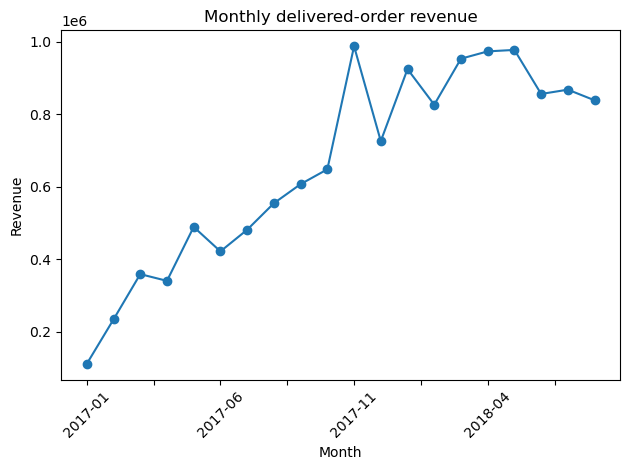

In [28]:
# [1.5-C] 월별 매출 추이
#
# 힌트:
# kind = "line"
# x = "month"
# y = "revenue"

ax = monthly_sales_df.plot(
    kind="line",
    x="month",
    y="revenue",
    marker="o",
    legend=False
)

ax.set_title("Monthly delivered-order revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:
# [1.5-D] 2017-11 vs 2017-12 카테고리별 변화
#
# 힌트
# - 카테고리: 번역명이 있으면 영어명, 없으면 원래 카테고리명
# - revenue = SUM(oi.price)
# - delivered만 사용
# - 기간: '2017-11-01' 이상, '2018-01-01' 미만
# - 11월/12월 매출은 conditional aggregation으로 같은 행에 배치
#
# 주의:
# 카테고리별 단순 LAG는 어떤 달의 데이터가 없으면
# '직전 월'이 아닌 '직전에 존재하는 달'을 비교할 수 있습니다.

category_change_sql = """
WITH category_monthly_sales AS (
    SELECT
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ) AS category,

        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_products_dataset AS pr
      ON oi.product_id = pr.product_id
    LEFT JOIN product_category_name_translation AS tr
      ON pr.product_category_name = tr.product_category_name

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-11-01'
      AND o.order_purchase_timestamp <  '2018-01-01'

    GROUP BY
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ),
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        )
),

category_compare AS (
    SELECT
        category,

        SUM(
            CASE
                WHEN month = '2017-11' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_11,

        SUM(
            CASE
                WHEN month = '2017-12' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_12

    FROM category_monthly_sales
    GROUP BY category
)

SELECT
    category,
    ROUND(revenue_2017_11, 2) AS revenue_2017_11,
    ROUND(revenue_2017_12, 2) AS revenue_2017_12,

    ROUND(
        revenue_2017_12 - revenue_2017_11,
        2
    ) AS change_amount

FROM category_compare
ORDER BY change_amount ASC
LIMIT 10;
"""

category_change_df = run_sql(category_change_sql)
category_change_df


,category,revenue_2017_11,revenue_2017_12,change_amount
0,bed_bath_table,87957.63,50081.16,-37876.47
1,computers_accessories,69676.32,37428.67,-32247.65
2,furniture_decor,62091.27,31073.09,-31018.18
3,watches_gifts,95292.34,69556.92,-25735.42
4,cool_stuff,55696.66,37515.57,-18181.09
5,health_beauty,78274.40,60688.75,-17585.65
6,garden_tools,44275.18,26795.69,-17479.49
7,telephony,26117.63,12780.44,-13337.19
8,office_furniture,17919.20,6684.37,-11234.83
9,agro_industry_and_commerce,13932.49,5291.70,-8640.79


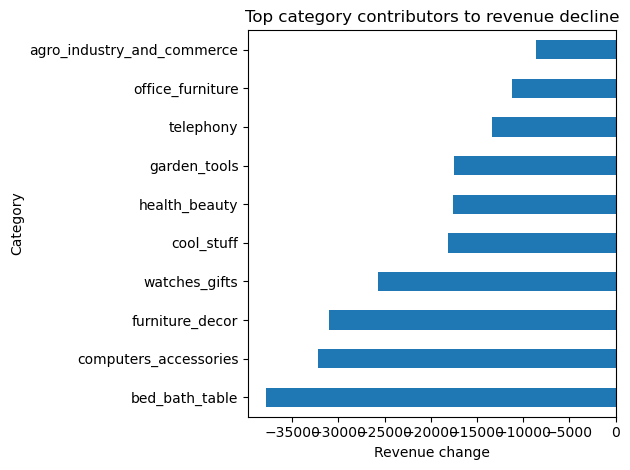

In [30]:
# [1.5-E] 감소 기여 Top 10 그래프
#
# 힌트:
# kind = "barh"
# x = "category"
# y = "change_amount"

plot_df = category_change_df.sort_values("change_amount")

ax = plot_df.plot(
    kind="barh",
    x="category",
    y="change_amount",
    legend=False
)

ax.set_title("Top category contributors to revenue decline")
ax.set_xlabel("Revenue change")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


### 1.5 해석
1. 가장 큰 매출 감소 시점은?
2017년 12월
2. 감소 폭은?
261,732.18
3. 감소에 크게 기여한 카테고리는?
bed_bath_table
4. 이 결과만으로 실제 **원인**을 확정할 수 있는가?
확정할 수는 없다. 카테고리별 매출 변화량을 분해한 것이므로 어떤 카테고리에서 매출이 많이 감소했는지는 알 수 있지만, 해당 감소가 왜 발생했는지는 확인할 수 없다.
5. 추가로 필요한 데이터는?
상품 가격 변화, 할인 및 프로모션 여부 등



# 2. 심화 과제 — 아래 중 1개 선택


### A. 배송
배송 지연이 많은 판매자 또는 카테고리 분석

### B. 고객
1회 구매 고객 vs 2회 이상 구매 고객 평균 주문금액 비교

### C. 매출
매출 변화가 큰 시점을 지역 또는 카테고리 관점에서 분해

### D. 자유 분석
상급자에게 보고할 가치가 있는 질문을 직접 정의


In [34]:
# [심화 과제 공통 Skeleton]
#
# 1) 분석 Grain을 먼저 주석으로 적으세요.
# 2) JOIN Key를 먼저 확인하세요.
# 3) 집계 전/후 행 수 검증 쿼리를 최소 1개 포함하세요.
# 4) 핵심 지표를 2개 이상 만드세요.

# [심화 과제 A] 배송 지연이 많은 판매자 분석
#
# Grain
# - order_seller: 1 row = 1 order × 1 seller
# - base: 1 row = 1 order × 1 seller
# - summary: 1 row = 1 seller
#
# JOIN Key: order_id

deep_dive_sql = """
WITH order_seller AS (
    SELECT
        order_id,
        seller_id
    FROM olist_order_items_dataset
    GROUP BY order_id, seller_id
),

base AS (
    SELECT
        o.order_id,
        os.seller_id,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date,

        DATEDIFF(
            o.order_delivered_customer_date,
            o.order_estimated_delivery_date
        ) AS delay_days,

        CASE
            WHEN DATEDIFF(
                o.order_delivered_customer_date,
                o.order_estimated_delivery_date
            ) > 0 THEN 1
            ELSE 0
        END AS is_delayed

    FROM olist_orders_dataset AS o

    JOIN order_seller AS os
      ON o.order_id = os.order_id

    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
),

summary AS (
    SELECT
        seller_id,
        COUNT(*) AS order_count,
        SUM(is_delayed) AS delayed_order_count,

        ROUND(
            100.0 * SUM(is_delayed) / COUNT(*),
            2
        ) AS delay_rate_pct,

        ROUND(
            AVG(delay_days),
            2
        ) AS avg_delay_days,

        ROUND(
            AVG(
                CASE
                    WHEN is_delayed = 1 THEN delay_days
                    ELSE NULL
                END
            ),
            2
        ) AS avg_delay_days_when_delayed

    FROM base
    GROUP BY seller_id
)

SELECT *
FROM summary
ORDER BY delayed_order_count DESC, delay_rate_pct DESC
LIMIT 10;
"""

deep_dive_df = run_sql(deep_dive_sql)
deep_dive_df

,seller_id,order_count,delayed_order_count,delay_rate_pct,avg_delay_days,avg_delay_days_when_delayed
0,4a3ca9315b744ce9f8e9374361493884,1772,172.0,9.71,-9.53,11.23
1,1f50f920176fa81dab994f9023523100,1399,124.0,8.86,-10.37,10.59
2,4869f7a5dfa277a7dca6462dcf3b52b2,1124,118.0,10.50,-11.10,9.25
3,ea8482cd71df3c1969d7b9473ff13abc,1132,96.0,8.48,-9.96,8.17
4,6560211a19b47992c3666cc44a7e94c0,1819,96.0,5.28,-11.49,7.74
5,7c67e1448b00f6e969d365cea6b010ab,973,89.0,9.15,-11.38,12.31
6,da8622b14eb17ae2831f4ac5b9dab84a,1311,87.0,6.64,-10.98,11.48
7,cc419e0650a3c5ba77189a1882b7556a,1651,87.0,5.27,-12.99,7.86
8,8b321bb669392f5163d04c59e235e066,930,81.0,8.71,-9.95,9.77
9,955fee9216a65b617aa5c0531780ce60,1261,77.0,6.11,-10.22,8.53


## Grain 검증

In [35]:
deep_dive_validation_sql = """
WITH order_seller AS (
    SELECT
        order_id,
        seller_id
    FROM olist_order_items_dataset
    GROUP BY order_id, seller_id
),

base AS (
    SELECT
        o.order_id,
        os.seller_id
    FROM olist_orders_dataset AS o
    JOIN order_seller AS os
      ON o.order_id = os.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
)

SELECT
    COUNT(*) AS total_rows,
    COUNT(
        DISTINCT CONCAT(order_id, '|', seller_id)
    ) AS distinct_order_seller
FROM base;
"""

deep_dive_validation_df = run_sql(deep_dive_validation_sql)
deep_dive_validation_df

,total_rows,distinct_order_seller
0,97811,97811


### 심화 과제 작성
- 분석 질문: 어떤 판매자가 배송 지연 주문이 많으며, 판매자별 배송 지연율은 어떻게 다른가?
- 분석 Grain: base: 1행 = 1주문 × 1판매자, summary: 1행 = 1판매자
- 사용 테이블: olist_orders_dataset, olist_order_items_dataset
- JOIN Key: order_id
- 지표 / 파생변수: 주문 수, 지연 주문 수, 지연율, 평균 지연일, 지연 주문의 평균 지연일
- 필터 기준: delivered 주문 중 실제 배송일과 예상 배송일이 존재하는 주문만 사용
- 검증 방법: 전체 97,811행과 고유 order_id + seller_id 조합 97,811개가 같은지 확인
- 핵심 숫자 2~3개: 4a3ca... 판매자는 지연 주문이 172건으로 가장 많았고 지연율은 9.71%였다. 4869f...는 지연율이 10.50%로 높았고, 7c67e...는 지연 주문의 평균 지연일이 12.31일이었다.
- 해석: 판매자별로 지연 건수와 지연율에 차이가 있었으며, 주문량이 다르므로 지연 건수와 지연율을 함께 볼 필요가 있다.
- 한계 / 추가 분석: 배송 지연이 판매자 때문이라고 단정할 수 없으며, 배송 거리·지역·물류업체·상품 종류 등도 함께 확인할 필요가 있다.


#### 🤔 회고

Part A에서 겪은 어려움과 해결 과정을 3-5문장으로 적습니다. 끝까지 헷갈린 개념 1-3개도 함께: (order_items와 payments처럼 한 주문에 여러 행이 존재하는 테이블을 JOIN하면 같은 order_id가 반복될 수 있다는 것을 확인했다. 그래서 order_mart를 만든 뒤 len(order_mart_df)로 전체 행 수를 구하고, order_mart_df["order_id"].nunique()로 고유 주문 수를 구해 두 값을 비교하였다. 실제로 두 값이 모두 99,441로 같았고, assert total_rows == unique_orders가 통과하면서 1 row = 1 order라는 Grain이 제대로 유지된 것을 확인할 수 있었다.)

Part B(심화 선택)를 진행했다면, 새롭게 알게 된 점을 이어서 적어도 좋습니다: (여기에 답)

#### ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답)

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
(여기에 AI와의 실제 대화 내역을 붙여넣기)
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요? (여기에 답)